# OBB Feature Extraction & Analysis

Extract Oriented Bounding Box features from BIM meshes.

**Features:**
- Length (L): Maximum OBB extent
- Cross Section Area (C): Area perpendicular to longest axis (W × H)
- Volume (V): OBB volume (L × W × H)
- Number of Vertices (N): Mesh complexity

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from extractors.obb_extractor import OBBFeatureExtractor, DEFAULT_EXCLUDED_TYPES

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Paths
DATA_DIR = Path('/Users/sercanamac/Bentley3D/processed_data/meshes')
OUTPUT_DIR = Path('/Users/sercanamac/Bentley3D/processed_data/features')

## 1. Feature Extraction

In [2]:
extractor = OBBFeatureExtractor(
    metadata_path=DATA_DIR / 'metadata.json',
    excluded_types=DEFAULT_EXCLUDED_TYPES
)

df = extractor.extract_all(
    mesh_dir=DATA_DIR / 'train',
    batch_size=5000,
    split='train'
)

Loaded metadata: 246,893 elements
Files: 158,191 -> 132,734 after filtering


Batch 1/27:   0%|          | 0/5000 [00:00<?, ?it/s]

Batch 2/27:   0%|          | 0/5000 [00:00<?, ?it/s]

Batch 3/27:   0%|          | 0/5000 [00:00<?, ?it/s]

Batch 4/27:   0%|          | 0/5000 [00:00<?, ?it/s]

...

Batch 24/27:   0%|          | 0/5000 [00:00<?, ?it/s]

Batch 25/27:   0%|          | 0/5000 [00:00<?, ?it/s]

Batch 26/27:   0%|          | 0/5000 [00:00<?, ?it/s]

Batch 27/27:   0%|          | 0/2734 [00:00<?, ?it/s]

Success: 128,883, Failed: 3,851


## 2. Dataset Overview

In [4]:
print(f'Dataset shape: {df.shape}')
print(f'IFC types: {df["IfcType"].nunique()}')
print()
print('=== Feature Statistics ===')
print(df[['Length', 'CrossSectionArea', 'Volume', 'NumVertices']].describe())
print()
print('=== IFC Type Distribution ===')
print(df['IfcType'].value_counts())

Dataset shape: (128883, 7)
IFC types: 24

=== Feature Statistics ===
              Length  CrossSectionArea         Volume    NumVertices
count  128883.000000     128883.000000  128883.000000  128883.000000
mean        3.542200          0.331663       2.932638     407.159990
std         5.458581          0.988667      28.121494    2895.532497
min         0.025000          0.000007       0.000002       6.000000
25%         1.132067          0.013000       0.019500       8.000000
50%         2.040000          0.090000       0.201096      20.000000
75%         3.811046          0.363012       0.864000     100.000000
max        68.000000         86.212178    3896.681586  109244.000000

=== IFC Type Distribution ===
IfcType
IfcMember                     23522
IfcPlate                      19693
IfcFurniture                  14525
IfcBuildingElementProxy       11821
IfcWall                       11778
IfcWindow                      9895
IfcColumn                      8418
IfcBeam            

## 3. Feature Distributions

Define plotting functions and visualize each feature separately.

In [5]:
features = ['Length', 'CrossSectionArea', 'Volume', 'NumVertices']

def plot_distribution(df, feature, bins=50, figsize=(10, 6)):
    """Plot histogram distribution for a single feature."""
    fig, ax = plt.subplots(figsize=figsize)
    data = np.log10(df[feature] + 1e-10)
    ax.hist(data, bins=bins, edgecolor='black', alpha=0.7)
    ax.set_xlabel(f'log10({feature})', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'{feature} Distribution', fontsize=14, fontweight='bold')
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.2f}')
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_boxplot_by_type(df, feature, top_n=24, figsize=(12, 10)):
    """Plot boxplot of feature by IFC type."""
    top_types = df['IfcType'].value_counts().head(top_n).index
    df_plot = df[df['IfcType'].isin(top_types)].copy()
    df_plot['log_feature'] = np.log10(df_plot[feature] + 1e-10)
    
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(
        data=df_plot,
        x='log_feature',
        y='IfcType',
        ax=ax,
        palette='Set2',
        order=top_types
    )
    ax.set_xlabel(f'log10({feature})', fontsize=12)
    ax.set_ylabel('IFC Type', fontsize=12)
    ax.set_title(f'{feature} by IFC Type', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

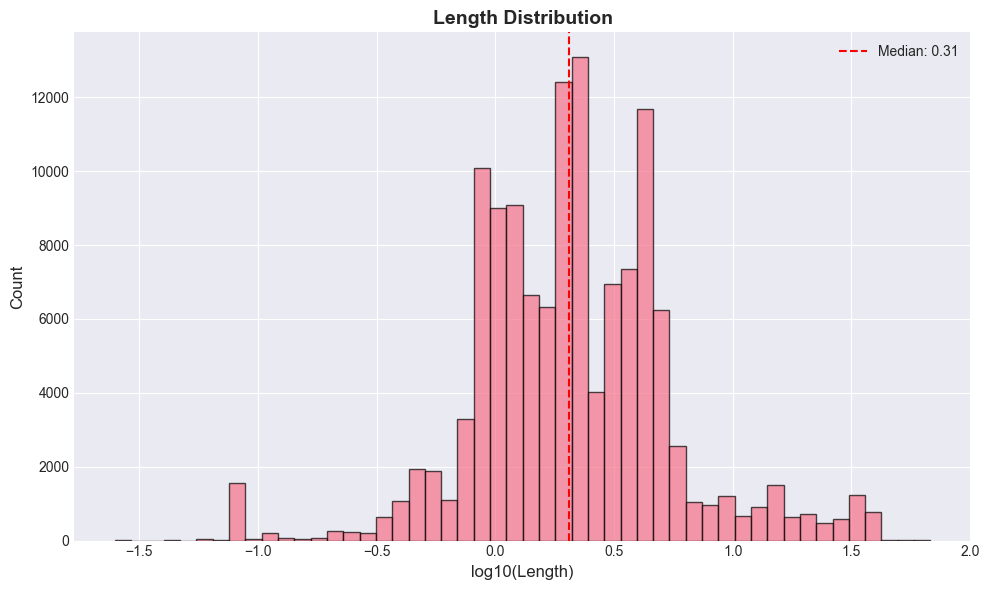

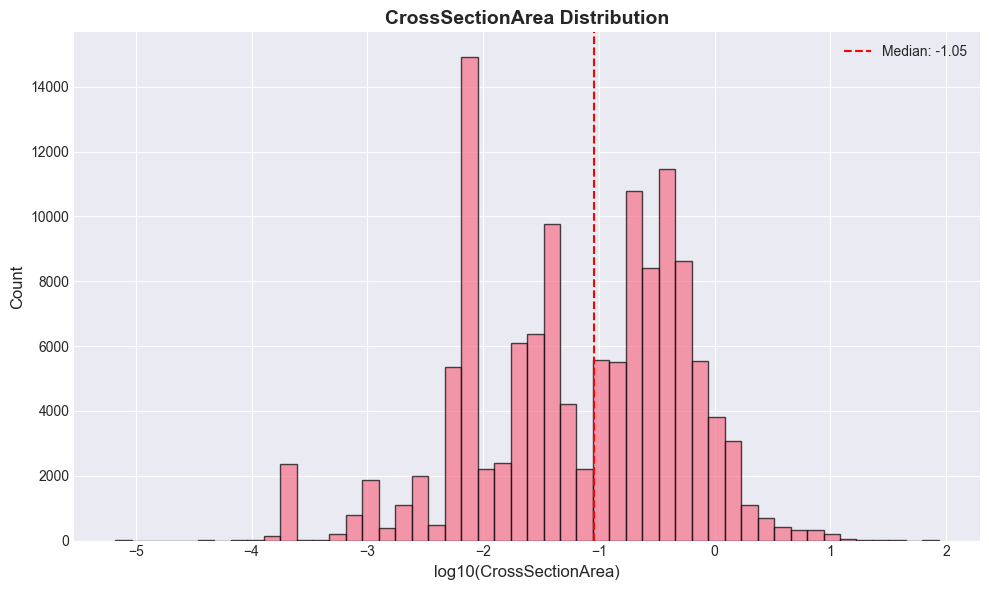

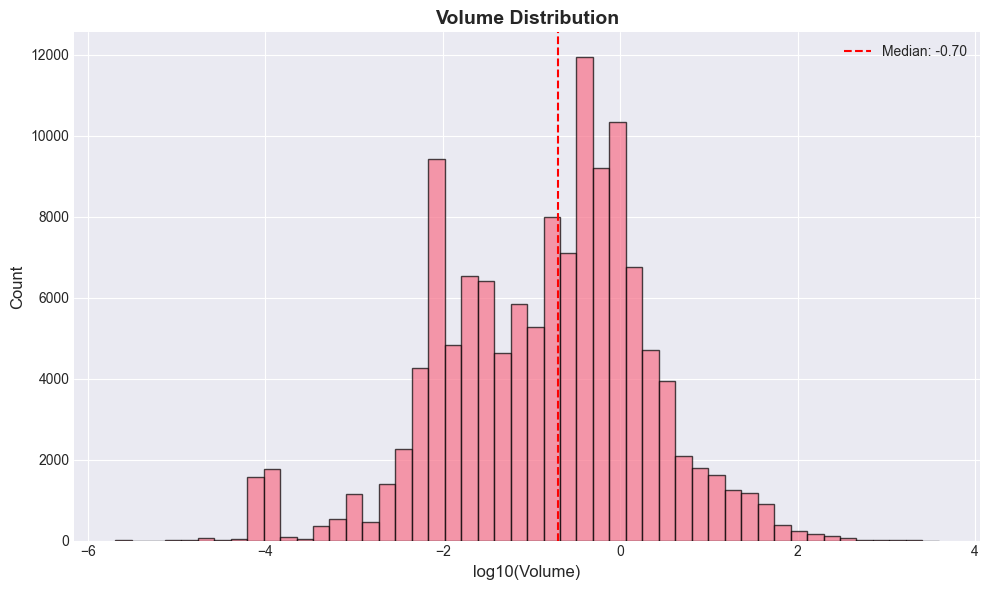

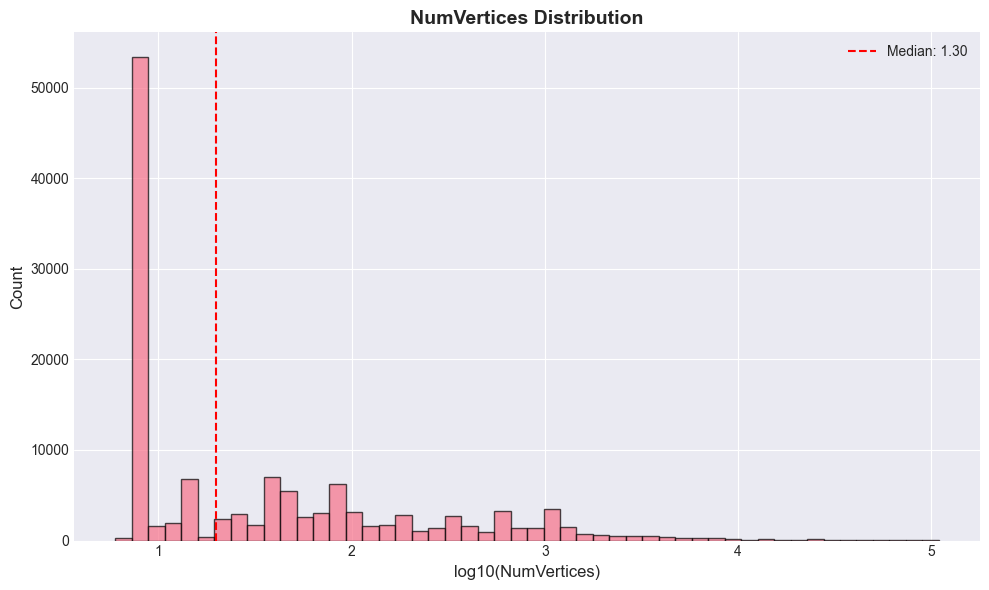

In [6]:
for feature in features:
    plot_distribution(df, feature)

## 4. Distributions by IFC Type

/var/folders/yh/gtl0xyw13glf6h9lcy5m_h180000gn/T/ipykernel_37106/3870967961.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


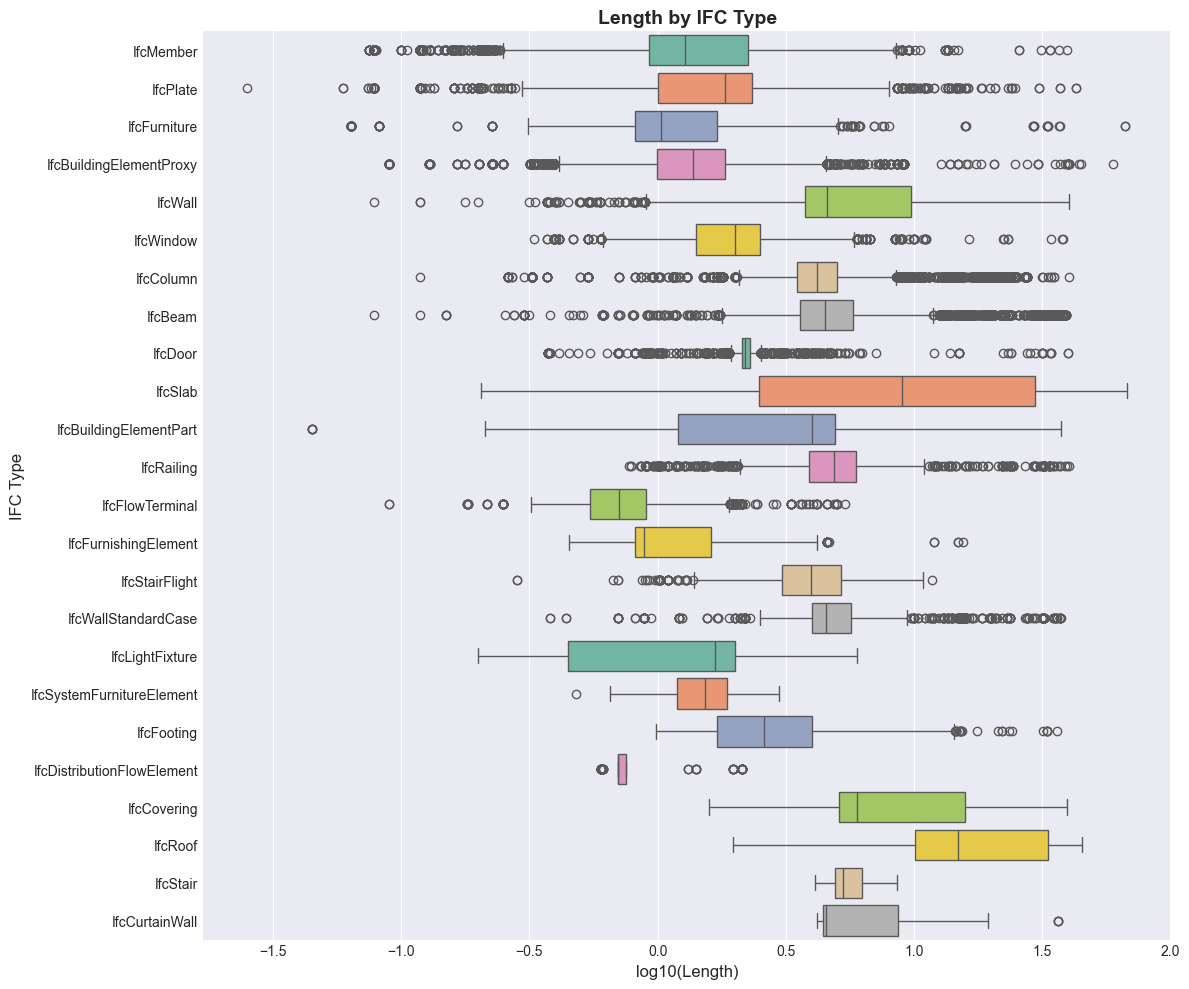

/var/folders/yh/gtl0xyw13glf6h9lcy5m_h180000gn/T/ipykernel_37106/3870967961.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


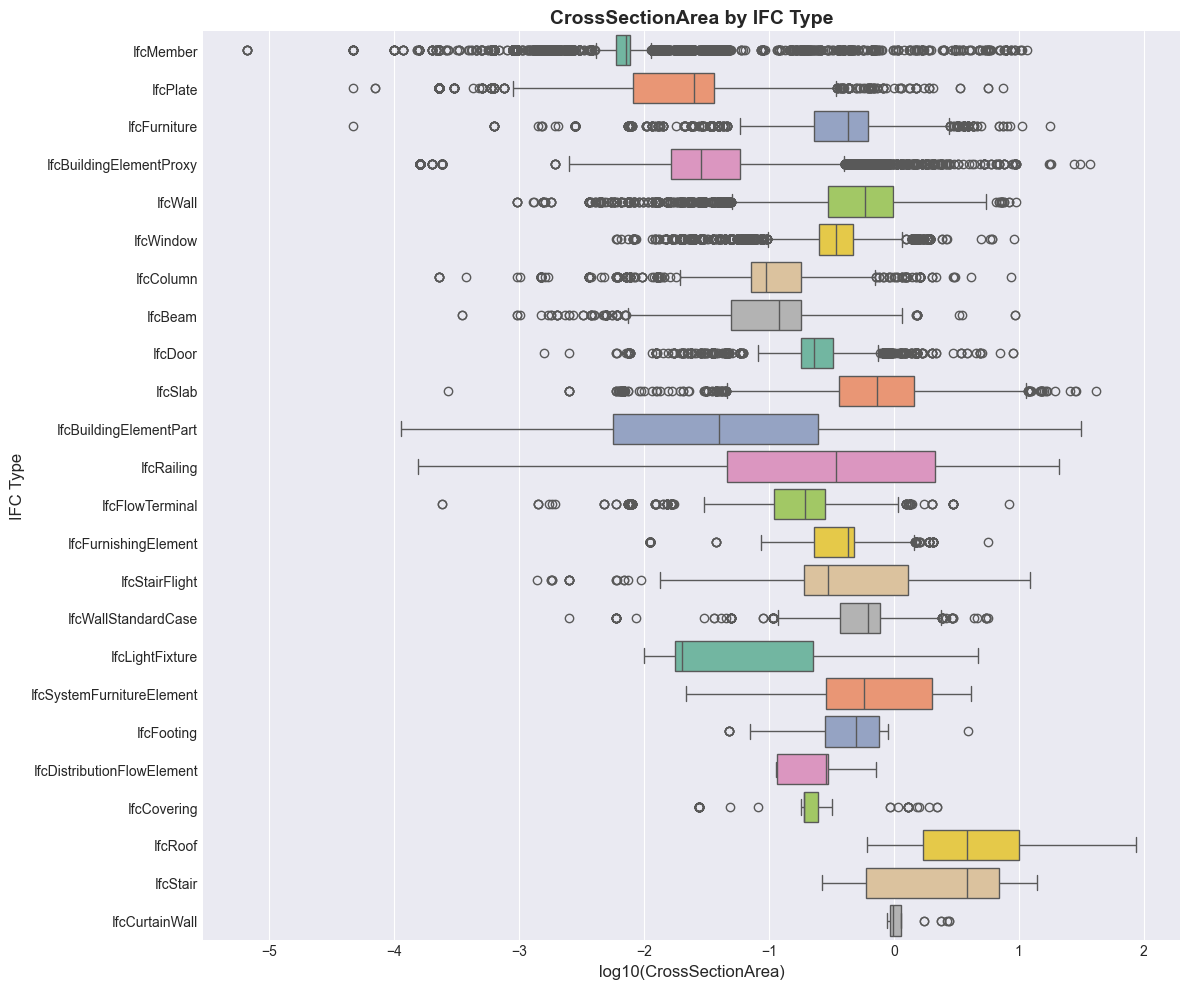

/var/folders/yh/gtl0xyw13glf6h9lcy5m_h180000gn/T/ipykernel_37106/3870967961.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


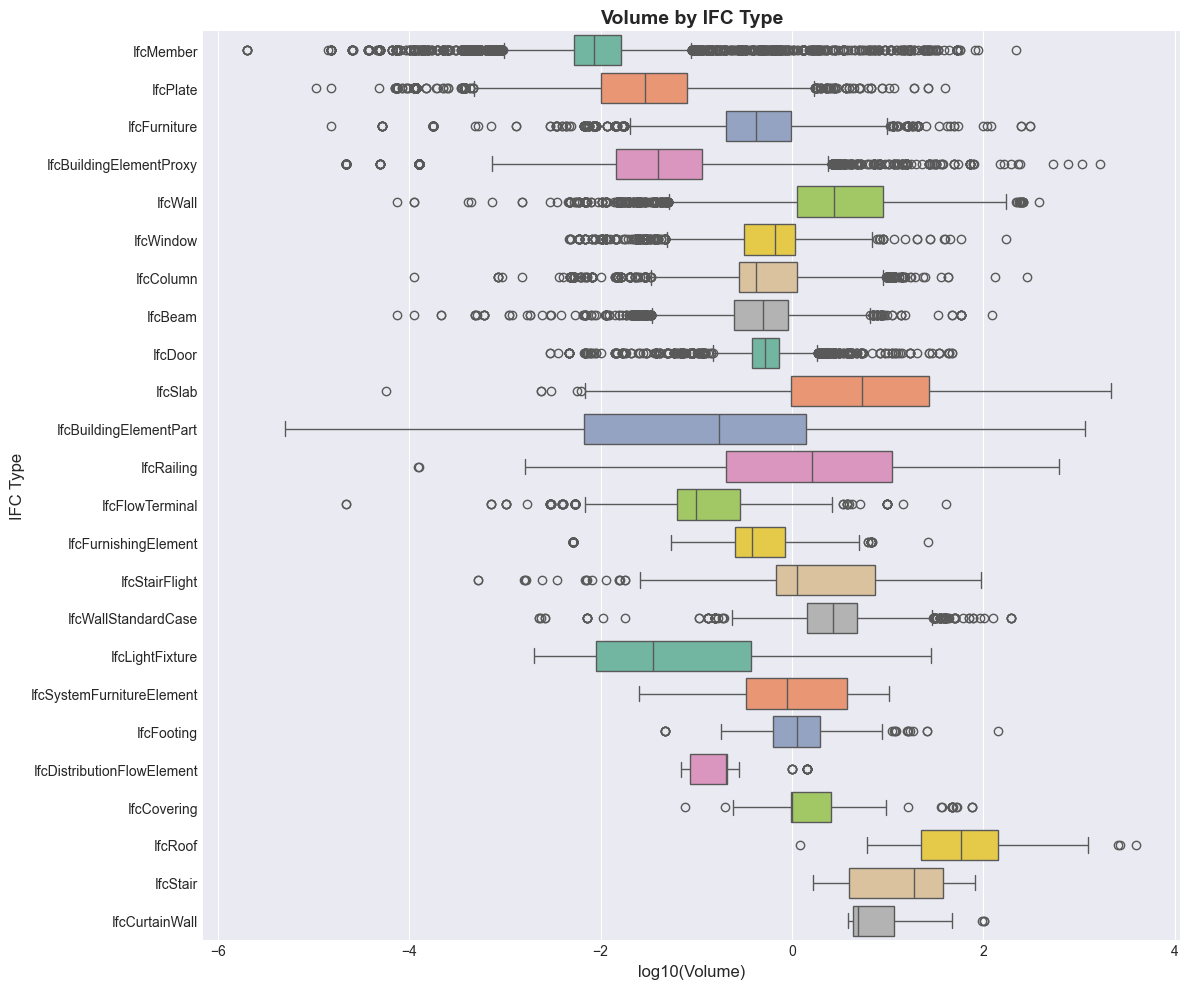

/var/folders/yh/gtl0xyw13glf6h9lcy5m_h180000gn/T/ipykernel_37106/3870967961.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


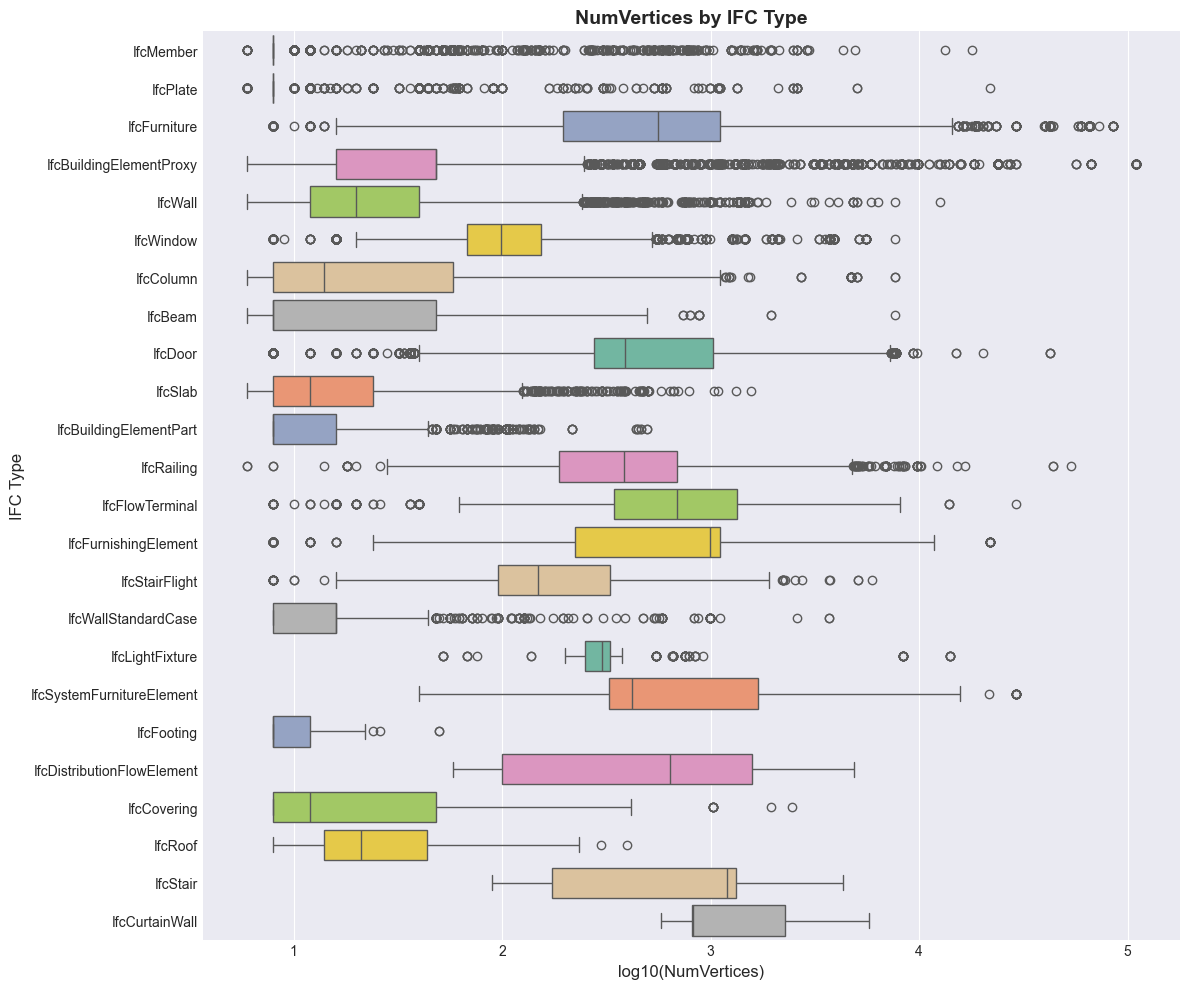

In [7]:
for feature in features:
    plot_boxplot_by_type(df, feature)

## 5. Feature Correlations

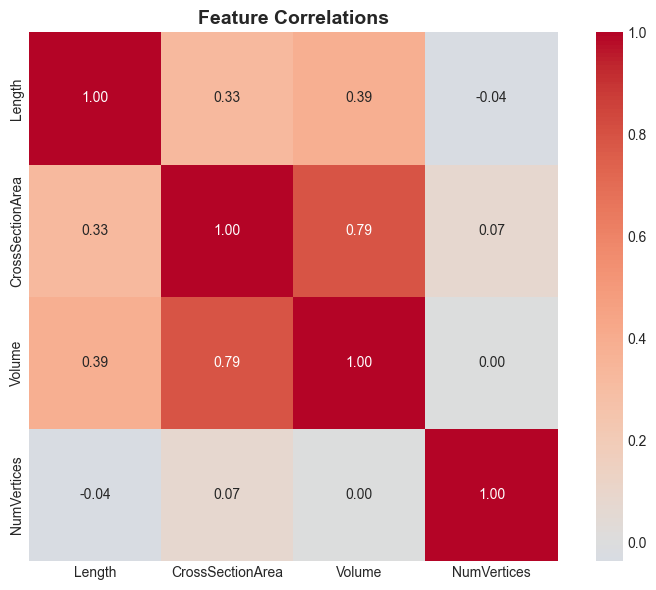

In [8]:
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, ax=ax)
ax.set_title('Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Summary Statistics

In [9]:
stats = df.groupby('IfcType').agg({
    'Length': ['count', 'mean', 'std', 'median'],
    'CrossSectionArea': ['mean', 'std', 'median'],
    'Volume': ['mean', 'std', 'median'],
    'NumVertices': ['mean', 'std', 'median']
}).round(4)

print('=== Feature Statistics by IFC Type ===')
stats

=== Feature Statistics by IFC Type ===


Length                            CrossSectionArea  \
                            count     mean      std   median             mean   
IfcType                                                                         
IfcBeam                      7856   6.4569   6.4677   4.5073           0.1296   
IfcBuildingElementPart       2844   6.2574   8.3903   4.0000           0.3303   
IfcBuildingElementProxy     11821   1.6789   1.9754   1.3720           0.1578   
IfcColumn                    8418   6.0548   5.3767   4.2000           0.1502   
IfcCovering                   114  12.1449  10.8443   6.0000           0.3365   
IfcCurtainWall                 42   8.9708   8.6525   4.5500           1.2173   
IfcDistributionFlowElement    124   0.9216   0.5037   0.7027           0.2785   
IfcDoor                      5548   2.3099   1.6489   2.2000           0.2949   
IfcFlowTerminal              1789   0.8803   0.6101   0.7050           0.2606   
IfcFooting                    188   5.2344   7.0493   2.6000           0.5242   
IfcFurnishingElement         1719   1.2940   0.9440   0.8883           0.4598   
IfcFurniture                14525   1.3471   1.3201   1.0287           0.5252   
IfcLightFixture               340   1.3909   0.8676   1.6742           0.1383   
IfcMember                   23522   1.6451   1.3424   1.2812           0.0316   
IfcPlate                    19693   1.9964   1.5248   1.8300           0.0301   
IfcRailing                   2324   5.7062   4.8043   4.8786           1.7860   
IfcRoof                        79  20.6809  12.2203  14.8000           8.7048   
IfcSlab                      3496  14.1014  13.5022   8.9999           1.4355   
IfcStair                       75   5.6887   1.1495   5.3026           4.3359   
IfcStairFlight               1291   4.1141   1.6090   3.9666           1.3682   
IfcSystemFurnitureElement     255   1.4990   0.4117   1.5240           0.9586   
IfcWall                     11778   8.5608   8.7946   4.6000           0.7248   
IfcWallStandardCase          1147   6.7886   6.7181   4.5500           0.6651   
IfcWindow                    9895   2.0958   1.2565   2.0000           0.4083   

                                               Volume                     \
                                std  median      mean       std   median   
IfcType                                                                    
IfcBeam                      0.1852  0.1200    0.8795    2.4745   0.5016   
IfcBuildingElementPart       2.2430  0.0400    8.0651   82.8171   0.1735   
IfcBuildingElementProxy      0.7869  0.0284    0.8404   20.8854   0.0399   
IfcColumn                    0.1957  0.0940    1.0542    3.9338   0.4230   
IfcCovering                  0.4583  0.1915    7.8767   17.5757   0.9891   
IfcCurtainWall               0.5507  0.9828   15.0157   25.5070   4.9044   
IfcDistributionFlowElement   0.1766  0.2845    0.3143    0.4050   0.2064   
IfcDoor                      0.3331  0.2301    0.7573    1.9086   0.5265   
IfcFlowTerminal              0.3680  0.1933    0.3594    1.3139   0.0987   
IfcFooting                   0.3412  0.5000    3.3468   11.0554   1.1148   
IfcFurnishingElement         0.3564  0.4304    0.7035    1.0798   0.3829   
IfcFurniture                 0.4733  0.4311    0.9792    5.1416   0.4239   
IfcLightFixture              0.3862  0.0201    0.3799    2.2067   0.0353   
IfcMember                    0.3486  0.0072    0.1404    2.3931   0.0086   
IfcPlate                     0.1039  0.0250    0.0826    0.4987   0.0292   
IfcRailing                   2.9534  0.3425   12.0879   31.4249   1.6236   
IfcRoof                     15.4222  3.8580  251.8996  612.1057  58.4656   
IfcSlab                      2.2969  0.7303   35.8532   94.5081   5.3422   
IfcStair                     3.8069  3.8622   23.1528   20.1671  18.9669   
IfcStairFlight               2.2699  0.2996    6.5228   11.4872   1.1199   
IfcSystemFurnitureElement    0.8668  0.5806    1.7061    1.9034   0.8849   
IfcWall        

## 7. Derived Feature Analysis

Compute derived features for deeper geometric insight.

In [29]:
# Compute derived features
eps = 1e-10
df['Slenderness'] = np.sqrt(df['CrossSectionArea'] + eps) / df['Length']
df['MeshEfficiency'] = df['NumVertices'] / (df['Volume'] ** (2/3) + eps)
df['Compactness'] = (df['Volume'] ** (1/3)) / df['Length']

print("Derived features computed:")
print(df[['Slenderness', 'N / V', 'Compactness']].describe())

Derived features computed:


KeyError: "['N / V'] not in index"

In [25]:
def plot_type_means(df, x_col, y_col, title, logx=True, logy=True, figsize=(18, 12)):
    """Simple scatter plot: one point per IFC type (mean values)."""
    means = df.groupby('IfcType')[[x_col, y_col]].mean()
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(means[x_col], means[y_col], s=300, alpha=0.7, edgecolor='black')
    
    for ifc_type, row in means.iterrows():
        ax.annotate(ifc_type.replace('Ifc', ''), (row[x_col], row[y_col]), 
                   fontsize=18, ha='left', va='bottom')
    
    if logx:
        ax.set_xscale('log')
    if logy:
        ax.set_yscale('log')
    
    ax.set_xlabel(x_col, fontsize=24)
    ax.set_ylabel(y_col, fontsize=24)
    ax.set_title(title, fontsize=28, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

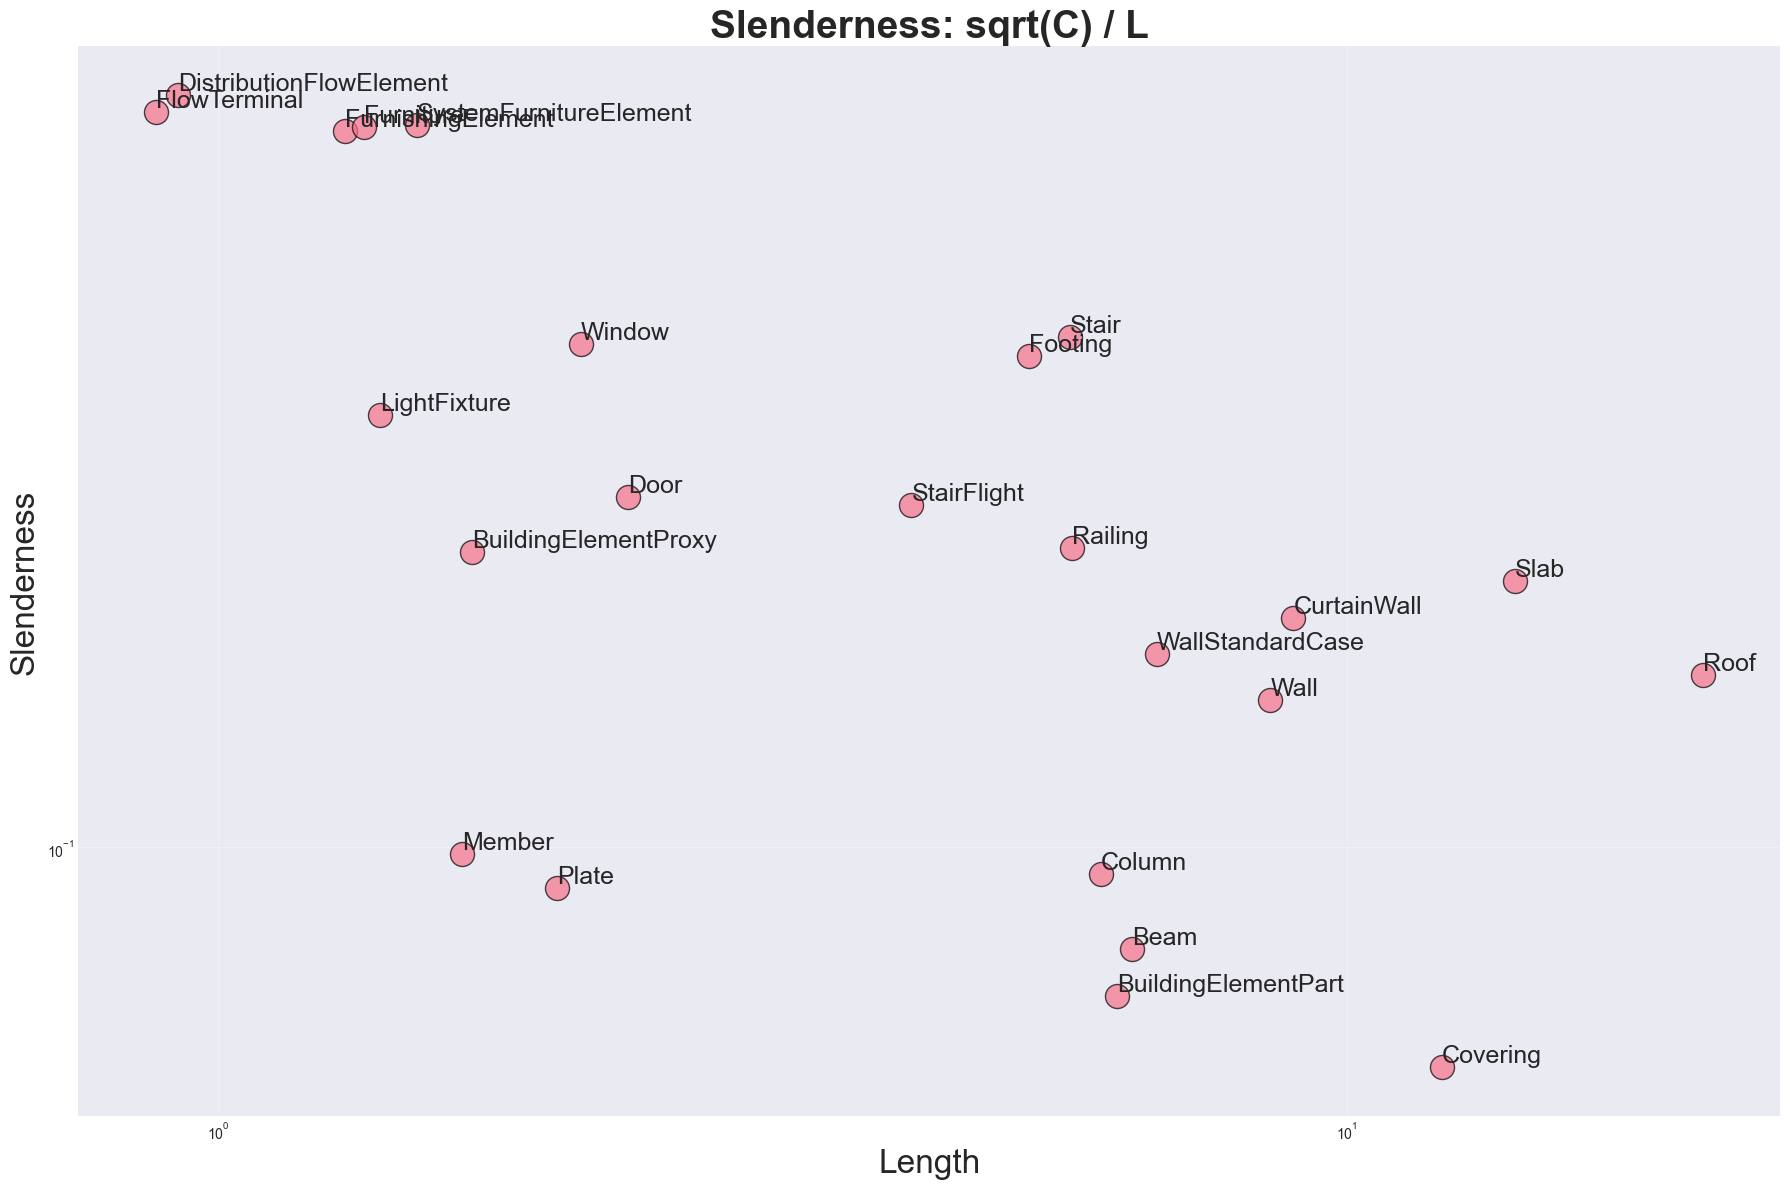

In [26]:
# Slenderness: Low = elongated (beams), High = chunky (footings)
plot_type_means(df, 'Length', 'Slenderness', 
                'Slenderness: sqrt(C) / L')

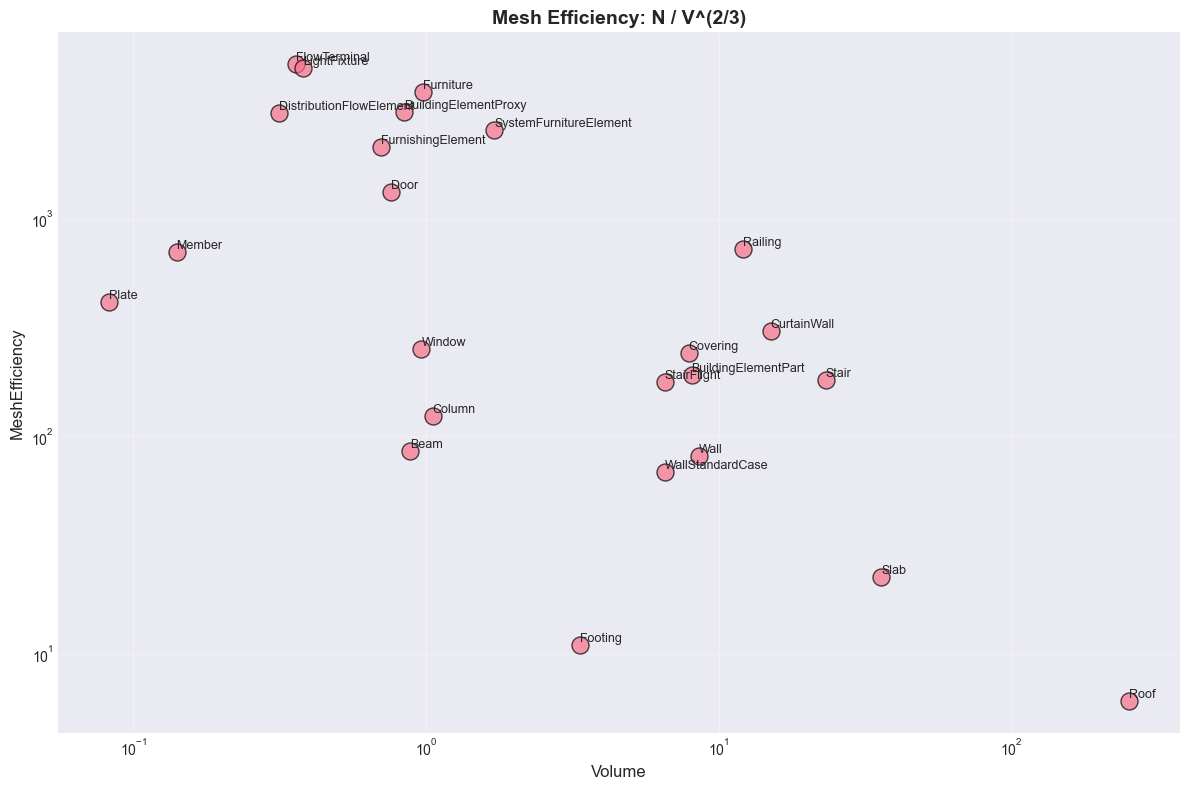

In [ ]:
# Mesh Efficiency: High = detailed mesh, Low = simple boxes
plot_type_means(df, 'Volume', 'N(vertices) / Volume',
                'N(vertices) / Volume : N / V')

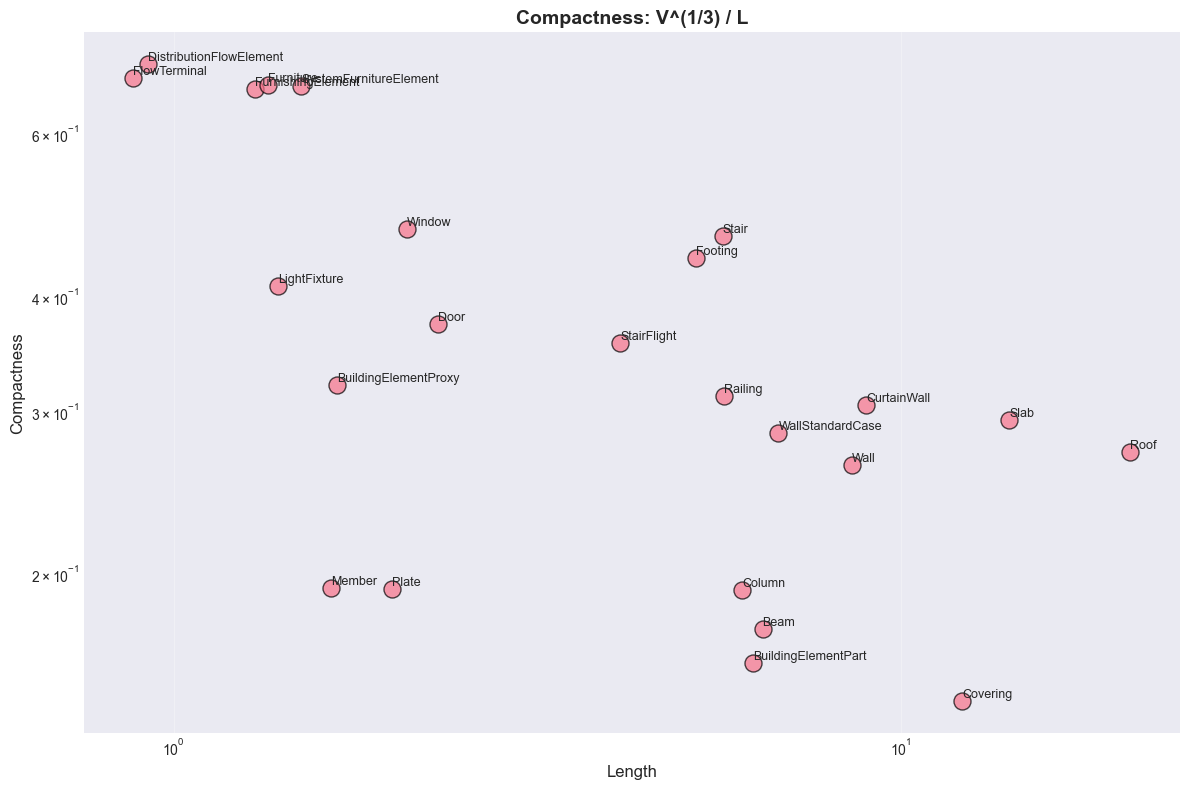

In [18]:
# Compactness: High = cube-like, Low = elongated
plot_type_means(df, 'Length', 'Compactness',
                'Compactness: V^(1/3) / L')

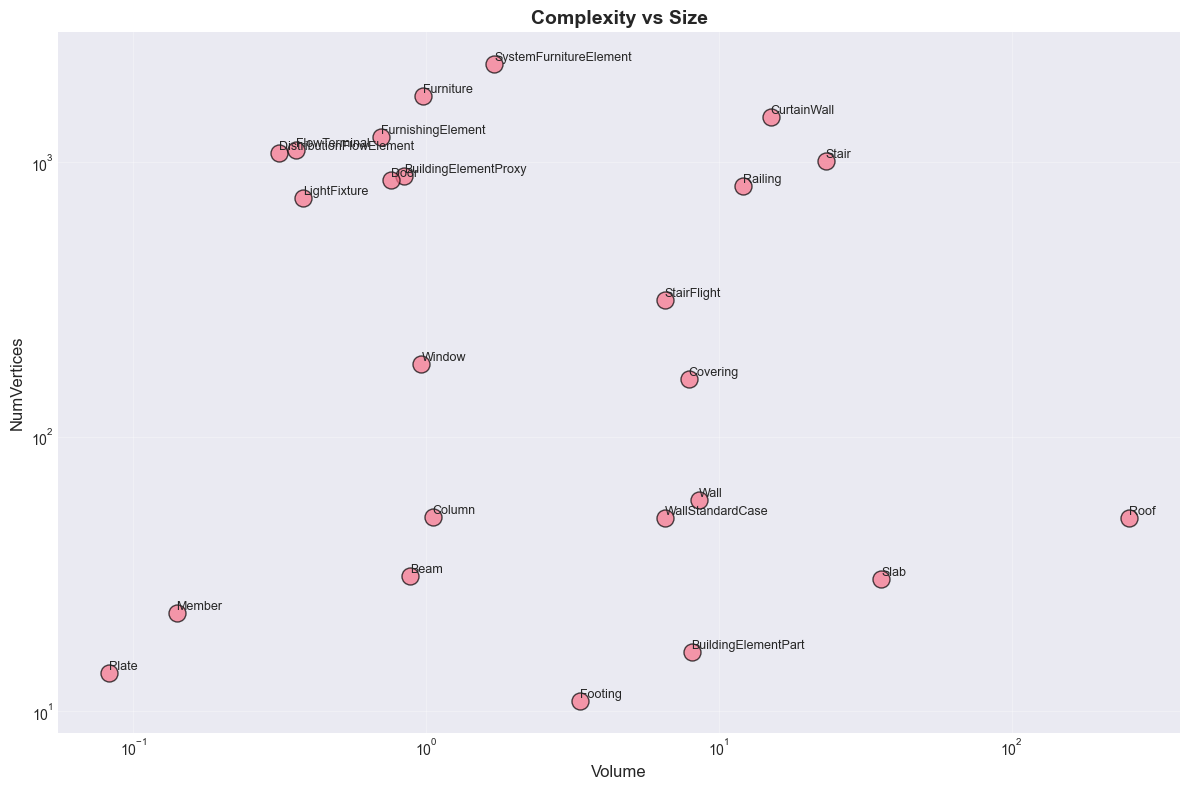

In [19]:
# Complexity vs Size
plot_type_means(df, 'Volume', 'NumVertices',
                'Complexity vs Size')

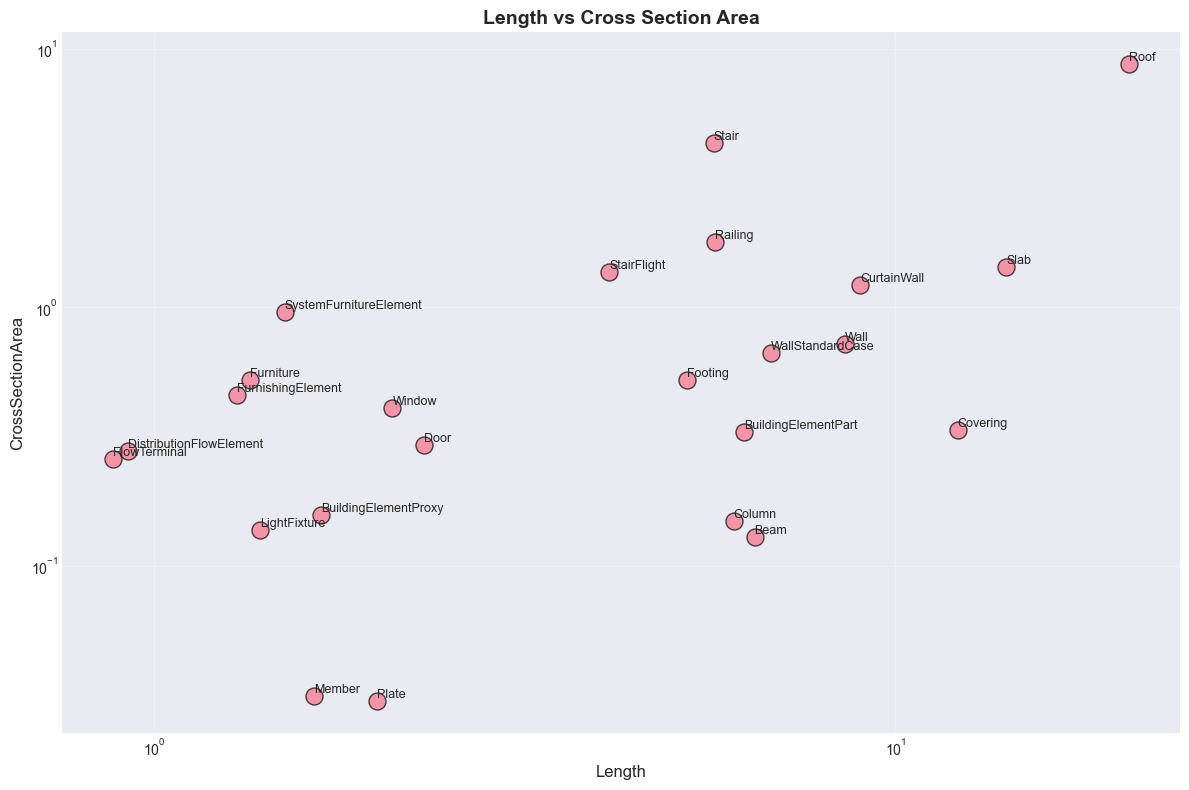

In [20]:
# Length vs CrossSectionArea
plot_type_means(df, 'Length', 'CrossSectionArea',
                'Length vs Cross Section Area')

In [3]:
extractor.save(df, Path("./processed_data/features"), "train_features" )

Saved to processed_data/features
